# 07 — DRL v3: PPO · M1Y WFO · Long+Short · 1h BTC · min-hold Constraint

## v3 fixes vs v2

| Problem (v2) | Root cause | Fix (v3) |
|---|---|---|
| 91% of folds trained negative Sharpe | step_penalty=0.20% corrupted gradient landscape; PPO paralysed | **Remove step_penalty** (structural constraint replaces reward punishment) |
| Trade count stayed at 2,368 (barely down from v1's 2,483) | Reward penalties don't cleanly block over-trading; PPO finds noisy workarounds | **min_hold=6** hard constraint in MarketEnv.step() — physically blocks position changes for 6h after entry |
| Zero-fee return collapsed to −21.6% (was +63.9% in v1) | Penalty overcorrection destroyed directional edge | Restore mild churn_penalty=0.10% + rely on min_hold to cut churn |

**Key insight:** Reward penalties corrupt PPO's gradient landscape. A hard min-hold constraint blocks over-trading
*mechanically* while leaving the PnL reward signal clean — PPO can still learn directional edge without navigating
a minefield of large punishment terms.

**Signal sanity (v1):** zero-fee upper bound was **+0.578 Sharpe / +63.9% return** — the directional edge exists.  
v3 targets **<400 trades** via the 6-bar mechanical hold (75% reduction vs v1's 2,483).

| Design dimension | Choice |
|---|---|
| **Algorithm** | PPO (Stable-Baselines3) |
| **WFO scheme** | M1Y sliding · 8760h train · 720h step · 92 folds |
| **Action space** | Discrete(3): Short / Flat / Long |
| **min_hold** | 6 bars (6h) — hard mechanical constraint in env.step() (NEW) |
| **step_penalty** | 0.0 — removed; min_hold replaces it structurally |
| **churn_penalty** | 0.10% on direct L↔S flip (mild; restored from v1) |
| **ent_coef** | 0.02 (kept from v2 — higher entropy → more exploration) |
| **PPO timesteps** | 500,000 (kept from v2) |
| **Taker fee** | 0.05% on entry/exit (unchanged) |
| **Episode length** | 1,000 bars · random start (unchanged) |


In [1]:
import calendar
import json
import time
import warnings
from pathlib import Path

import matplotlib as mpl
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from hmats.agents.drl_agent import DRLAgent, MarketEnv, _DEFAULT_DRL_FEATURES
from hmats.viz.plots import plot_equity_drawdown, save_fig

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.4f}'.format)

try:    plt.style.use('seaborn-v0_8-whitegrid')
except: plt.style.use('seaborn-whitegrid')
mpl.rcParams.update({
    'font.family': 'serif', 'font.serif': ['DejaVu Serif'],
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.labelsize': 10, 'axes.titlesize': 11,
    'xtick.labelsize': 9, 'ytick.labelsize': 9,
    'legend.fontsize': 9, 'legend.framealpha': 0.85,
    'figure.dpi': 120, 'savefig.dpi': 150, 'savefig.bbox': 'tight',
})
ACCENT='#F7931A'; BLUE='#2962FF'; GREY='#9E9E9E'
RED='#EF5350'; GREEN='#26A69A'; PURPLE='#7B1FA2'

# ── WFO / OOS config (mirrors LGBM v12) ──────────────────────────────────────
OOS_START       = pd.Timestamp('2024-01-01')
TRAIN_WINDOW_H  = 8760
STEP_SIZE       = 720
TOTAL_TIMESTEPS = 500_000   # v3: kept at 500k

# ── v3-specific hyperparameters ───────────────────────────────────────────────
EPISODE_LEN    = 1000       # unchanged
MIN_HOLD       = 6          # v3: hard 6h hold — blocks any position change for 6 bars (NEW)
CHURN_PENALTY  = 0.001      # v3: mild 0.10% on direct L↔S (restored from v1)
STEP_PENALTY   = 0.000      # v3: removed — min_hold replaces reward punishment
ENT_COEF       = 0.02       # kept from v2 — higher entropy

# ── Fee model ────────────────────────────────────────────────────────────────
TAKER_FEE   = 0.0005
FUNDING_H   = 0.0000077

print(f'Features     : {len(_DEFAULT_DRL_FEATURES)}  (market state + regime context)')
print(f'OOS start    : {OOS_START.date()}')
print(f'PPO ts/fold  : {TOTAL_TIMESTEPS:,}')
print(f'Episode len  : {EPISODE_LEN} bars  (random start)')
print(f'min_hold     : {MIN_HOLD} bars  (NEW — hard position-change block)')
print(f'Churn penalty: {CHURN_PENALTY:.3%}  (direct L↔S flip, mild)')
print(f'Step penalty : {STEP_PENALTY:.3%}  (removed in v3)')
print(f'ent_coef     : {ENT_COEF}  (kept from v2)')
print('Imports OK')

Features     : 19  (market state + regime context)
OOS start    : 2024-01-01
PPO ts/fold  : 500,000
Episode len  : 1000 bars  (random start)
min_hold     : 6 bars  (NEW — hard position-change block)
Churn penalty: 0.100%  (direct L↔S flip, mild)
Step penalty : 0.000%  (removed in v3)
ent_coef     : 0.02  (kept from v2)
Imports OK


In [2]:
def _find_repo_root() -> Path:
    p = Path.cwd()
    while p != p.parent:
        if (p / 'pyproject.toml').exists(): return p
        p = p.parent
    raise RuntimeError('repo root not found')

REPO_DIR = _find_repo_root()
FEAT_DIR = REPO_DIR / 'data' / 'features'
EXT_DIR  = REPO_DIR / 'data' / 'external'
ARTS_DIR = REPO_DIR / 'artifacts' / '07_drl_omni_0fee_v3'
ARTS_DIR.mkdir(parents=True, exist_ok=True)
print(f'Artifacts → {ARTS_DIR}')

Artifacts → /Users/wojciech.neuman/Documents/hybrid-multi-agent-trading-system/artifacts/07_drl_omni_0fee_v3


In [3]:
print('Loading V1 features...')
v1 = pd.read_parquet(FEAT_DIR / 'BTCUSDT_1h_features.parquet')
v1.index = v1.index.tz_localize(None) if v1.index.tz else v1.index

print('Loading V4 features...')
v4 = pd.read_parquet(FEAT_DIR / 'BTCUSDT_1h_v4_features.parquet')
v4.index = v4.index.tz_localize(None) if v4.index.tz else v4.index

merged = v1.copy()

_raw = pd.read_parquet(REPO_DIR / 'data' / 'raw' / 'BTCUSDT_1h.parquet')
_raw.index = _raw.index.tz_convert(None)
merged['high'] = _raw['high'].reindex(merged.index)
merged['low']  = _raw['low'].reindex(merged.index)

for col in ['close_vs_true_vwap', 'hurst_24h', 'hurst_72h', 'tfi_pct', 'tfi_z_24h',
            'bb_width_pct', 'sideways_flag']:
    if col in v4.columns:
        merged[col] = v4[col].reindex(merged.index)

present = [f for f in _DEFAULT_DRL_FEATURES if f in merged.columns]
missing = [f for f in _DEFAULT_DRL_FEATURES if f not in merged.columns]
print(f'Features present: {len(present)} / {len(_DEFAULT_DRL_FEATURES)}')
if missing: print(f'  Missing (will be 0): {missing}')

oos_mask = merged.index >= OOS_START
oos_df   = merged[oos_mask].copy()
print(f'Total bars: {len(merged):,}  |  OOS bars: {len(oos_df):,}')

Loading V1 features...
Loading V4 features...
Features present: 19 / 19
Total bars: 74,366  |  OOS bars: 20,785


In [4]:
# ── PHASE 1: Generate DRL WFO signals ────────────────────────────────────────
print('='*60)
print('PHASE 1 — M1Y WFO: PPO v3 signal generation')
print('='*60)
print(f'  v3 fixes active:')
print(f'    step_penalty  = {STEP_PENALTY:.3%} on ANY position change (NEW)')
print(f'    churn_penalty = {CHURN_PENALTY:.3%} on direct L\u2194S (raised from 0.10%)')
print(f'    ent_coef      = {ENT_COEF}  (raised from 0.01)')
print(f'    total_ts      = {TOTAL_TIMESTEPS:,}  (raised from 300,000)')

agent = DRLAgent(
    features=[f for f in _DEFAULT_DRL_FEATURES if f in merged.columns],
    window_size=24,
    episode_len=EPISODE_LEN,
    churn_penalty=CHURN_PENALTY,
    step_penalty=STEP_PENALTY,
    min_hold=MIN_HOLD,
    train_window_h=TRAIN_WINDOW_H,
    step_size=STEP_SIZE,
    total_timesteps=TOTAL_TIMESTEPS,
    agent_id='drl_ppo_v3',
    ppo_kwargs={'ent_coef': ENT_COEF},
)

t0 = time.time()
drl_signals = agent.generate_signals(merged, oos_start=OOS_START, verbose=True)
print(f'Done in {(time.time()-t0)/60:.1f} min')

sig_path = ARTS_DIR / 'drl_oos_signals.parquet'
drl_signals.to_frame().to_parquet(sig_path)
print(f'Signals saved \u2192 {sig_path}')

vc = drl_signals.value_counts().sort_index()
for k, v in vc.items():
    name = {-1: 'Short', 0: 'Flat', 1: 'Long'}.get(k, str(k))
    print(f'  {name:5}: {v:5,}  ({v/len(drl_signals)*100:.1f}%)')

PHASE 1 — M1Y WFO: PPO v3 signal generation
  v3 fixes active:
    step_penalty  = 0.000% on ANY position change (NEW)
    churn_penalty = 0.100% on direct L↔S (raised from 0.10%)
    ent_coef      = 0.02  (raised from 0.01)
    total_ts      = 500,000  (raised from 300,000)
  [drl_ppo_v3] fold   1  train_sharpe=+6.967  train_ret=+41.872%  train_bars=8,760  episode_len=1000
  [drl_ppo_v3] fold   2  train_sharpe=+6.860  train_ret=+44.712%  train_bars=8,760  episode_len=1000
  [drl_ppo_v3] fold   3  train_sharpe=-2.099  train_ret=-10.326%  train_bars=8,760  episode_len=1000
  [drl_ppo_v3] fold   4  train_sharpe=+6.208  train_ret=+30.951%  train_bars=8,760  episode_len=1000
  [drl_ppo_v3] fold   5  train_sharpe=+0.653  train_ret=+1.865%  train_bars=8,760  episode_len=1000
  [drl_ppo_v3] fold   6  train_sharpe=+5.419  train_ret=+53.961%  train_bars=8,760  episode_len=1000
  [drl_ppo_v3] fold   7  train_sharpe=+5.638  train_ret=+40.900%  train_bars=8,760  episode_len=1000
  [drl_ppo_v3] fol

In [5]:
# ── PHASE 2: Backtest (same ATR-based SL/TP as v1) ───────────────────────────
print('='*60)
print('PHASE 2 — OOS BACKTEST')
print('='*60)

def _sharpe(eq):
    r = np.diff(np.log(np.maximum(eq, 1e-12)))
    return float(r.mean() / (r.std(ddof=1) + 1e-12) * np.sqrt(24 * 365))

def _maxdd(eq):
    pk = np.maximum.accumulate(eq)
    return float(((eq - pk) / (pk + 1e-12)).min())


def run_drl_backtest(
    actions, close_arr, high_arr, low_arr, atr_arr,
    with_fees=True, sl_mult=2.0, tp_mult=3.0,
    min_hold=4, max_hold=24, cooldown=2,
):
    MAKER_FEE  = 0.0000
    SPOT_TAKER = TAKER_FEE
    FUT_TAKER  = TAKER_FEE
    MIN_SL     = 0.010

    n = len(close_arr)
    eq = np.ones(n); cur = 1.0
    trades = []

    in_pos = False; direction = None
    entry_px = sl_px = tp_px = entry_fee = funding = 0.0
    pos_eq = 1.0; hold_cnt = cd_cnt = 0

    for i in range(n):
        lo = low_arr[i]; hi = high_arr[i]; px = close_arr[i]
        act = int(actions[i])

        if in_pos:
            hold_cnt += 1
            if direction == 'short': funding += FUNDING_H
            eq[i] = pos_eq * (px / entry_px if direction == 'long'
                              else 1 + (entry_px - px) / entry_px)
            exited = False; exit_px = 0.; reason = ''; exit_fee = 0.

            if hold_cnt >= min_hold:
                if direction == 'long':
                    if   lo <= sl_px:                           exit_px=sl_px;  exited=True; reason='sl';    exit_fee=SPOT_TAKER if with_fees else 0.
                    elif hi >= tp_px:                           exit_px=tp_px;  exited=True; reason='tp';    exit_fee=MAKER_FEE
                    elif hold_cnt >= max_hold or act in (0,-1): exit_px=px;     exited=True; reason='close'; exit_fee=SPOT_TAKER if with_fees else 0.
                else:
                    if   hi >= sl_px:                           exit_px=sl_px;  exited=True; reason='sl';    exit_fee=FUT_TAKER  if with_fees else 0.
                    elif lo <= tp_px:                           exit_px=tp_px;  exited=True; reason='tp';    exit_fee=MAKER_FEE
                    elif hold_cnt >= max_hold or act in (0, 1): exit_px=px;     exited=True; reason='close'; exit_fee=FUT_TAKER  if with_fees else 0.

            if exited:
                gross = ((exit_px-entry_px)/entry_px if direction=='long'
                         else (entry_px-exit_px)/entry_px)
                net = gross - (entry_fee+exit_fee if with_fees else 0.) + funding
                cur = pos_eq*(1.+net); eq[i] = cur
                trades.append({'direction': direction, 'reason': reason,
                               'gross': gross, 'net': net, 'hold': hold_cnt})
                in_pos = False; cd_cnt = cooldown; funding = 0.
        elif cd_cnt > 0:
            cd_cnt -= 1; eq[i] = cur
        elif act != 0 and i+1 < n:
            atr = max(float(atr_arr[i]) if not np.isnan(atr_arr[i]) else MIN_SL, MIN_SL)
            direction = 'long' if act == 1 else 'short'
            entry_px = px
            entry_fee = SPOT_TAKER if with_fees else 0.
            if direction == 'long':
                sl_px = px*(1 - sl_mult*atr); tp_px = px*(1 + tp_mult*atr)
            else:
                sl_px = px*(1 + sl_mult*atr); tp_px = px*(1 - tp_mult*atr)
            in_pos=True; pos_eq=cur; hold_cnt=0; funding=0.
            eq[i] = cur
        else:
            eq[i] = cur

    if in_pos:
        px = close_arr[-1]
        gross = ((px-entry_px)/entry_px if direction=='long' else (entry_px-px)/entry_px)
        tf = SPOT_TAKER if direction=='long' else FUT_TAKER
        net = gross-(entry_fee+(tf if with_fees else 0.))+funding
        cur=pos_eq*(1.+net); eq[-1]=cur

    return eq, trades


_acts   = drl_signals.values
_close  = oos_df['close'].values
_high   = oos_df['high'].values
_low    = oos_df['low'].values
_atr    = oos_df['atr_14_pct'].values

eq_fees, tdf_fees_raw = run_drl_backtest(_acts, _close, _high, _low, _atr, with_fees=True)
eq_0fee, tdf_0fee_raw = run_drl_backtest(_acts, _close, _high, _low, _atr, with_fees=False)

def _tdf(raw): return pd.DataFrame(raw) if raw else pd.DataFrame(
    columns=['direction','reason','gross','net','hold'])

tdf_fees = _tdf(tdf_fees_raw)
tdf_0fee = _tdf(tdf_0fee_raw)

print(f'\n{"":22}  {"Trades":>7}  {"L/S":>9}  {"WinRate":>8}  {"Return":>8}  {"Sharpe":>7}  {"MaxDD":>7}')
print('\u2500'*75)
for lbl, eq, tdf in [
    ('With fees (primary)', eq_fees, tdf_fees),
    ('Zero-fee (upper)',    eq_0fee, tdf_0fee),
]:
    wr  = (tdf['net']>0).mean()                if len(tdf) else 0.
    n_l = int((tdf['direction']=='long').sum()) if len(tdf) else 0
    n_s = int((tdf['direction']=='short').sum())if len(tdf) else 0
    print(f'{lbl:22}  {len(tdf):>7}  {n_l:>4}/{n_s:<4}  {wr:>8.1%}  '
          f'{eq[-1]-1:>+7.1%}  {_sharpe(eq):>7.3f}  {_maxdd(eq):>7.2%}')

PHASE 2 — OOS BACKTEST

                         Trades        L/S   WinRate    Return   Sharpe    MaxDD
───────────────────────────────────────────────────────────────────────────
With fees (primary)        2484  1291/1193     44.2%   -93.0%   -3.121  -94.39%
Zero-fee (upper)           2484  1291/1193     49.9%   -17.2%   -0.223  -50.80%


In [6]:
# ── ATH display window ────────────────────────────────────────────────────────
_oos_end_px = oos_df['close'].iloc[-1]
_ath_mask   = merged['close'] >= _oos_end_px
ATH_START   = merged[_ath_mask].index[0] if _ath_mask.any() else oos_df.index[0]
_ath_offset = oos_df.index.searchsorted(ATH_START)
oos_ath     = oos_df.iloc[_ath_offset:]
oos_index_ath = oos_ath.index

def _rebase(arr): s = arr[_ath_offset:]; return s / s[0]

eq_fees_ath = _rebase(eq_fees)
eq_0fee_ath = _rebase(eq_0fee)

try:
    _spy = pd.read_parquet(EXT_DIR / 'sp500_daily.parquet')
    _spy.index = pd.to_datetime(_spy.index).tz_localize(None)
    _spy_h = _spy['close'].reindex(oos_index_ath, method='ffill').ffill().bfill()
    sp500_pct = (_spy_h / _spy_h.iloc[0] - 1) * 100
    print(f'SPY ATH-window return: {sp500_pct.iloc[-1]:+.1f}%')
except Exception as e:
    sp500_pct = None
    print(f'SPY load failed: {e}')

bh_pct = (oos_ath['close'].values / oos_ath['close'].iloc[0] - 1) * 100
print(f'BTC B&H (ATH window): {bh_pct[-1]:+.1f}%')
print(f'\nATH metrics:')
print(f'  w/ fees: ret={eq_fees_ath[-1]-1:+.2%}  Sharpe={_sharpe(eq_fees_ath):.3f}  MaxDD={_maxdd(eq_fees_ath):.2%}')
print(f'  0-fee  : ret={eq_0fee_ath[-1]-1:+.2%}  Sharpe={_sharpe(eq_0fee_ath):.3f}  MaxDD={_maxdd(eq_0fee_ath):.2%}')

SPY ATH-window return: +25.8%
BTC B&H (ATH window): -0.0%

ATH metrics:
  w/ fees: ret=-83.22%  Sharpe=-3.495  MaxDD=-86.16%
  0-fee  : ret=-20.45%  Sharpe=-0.450  MaxDD=-46.20%


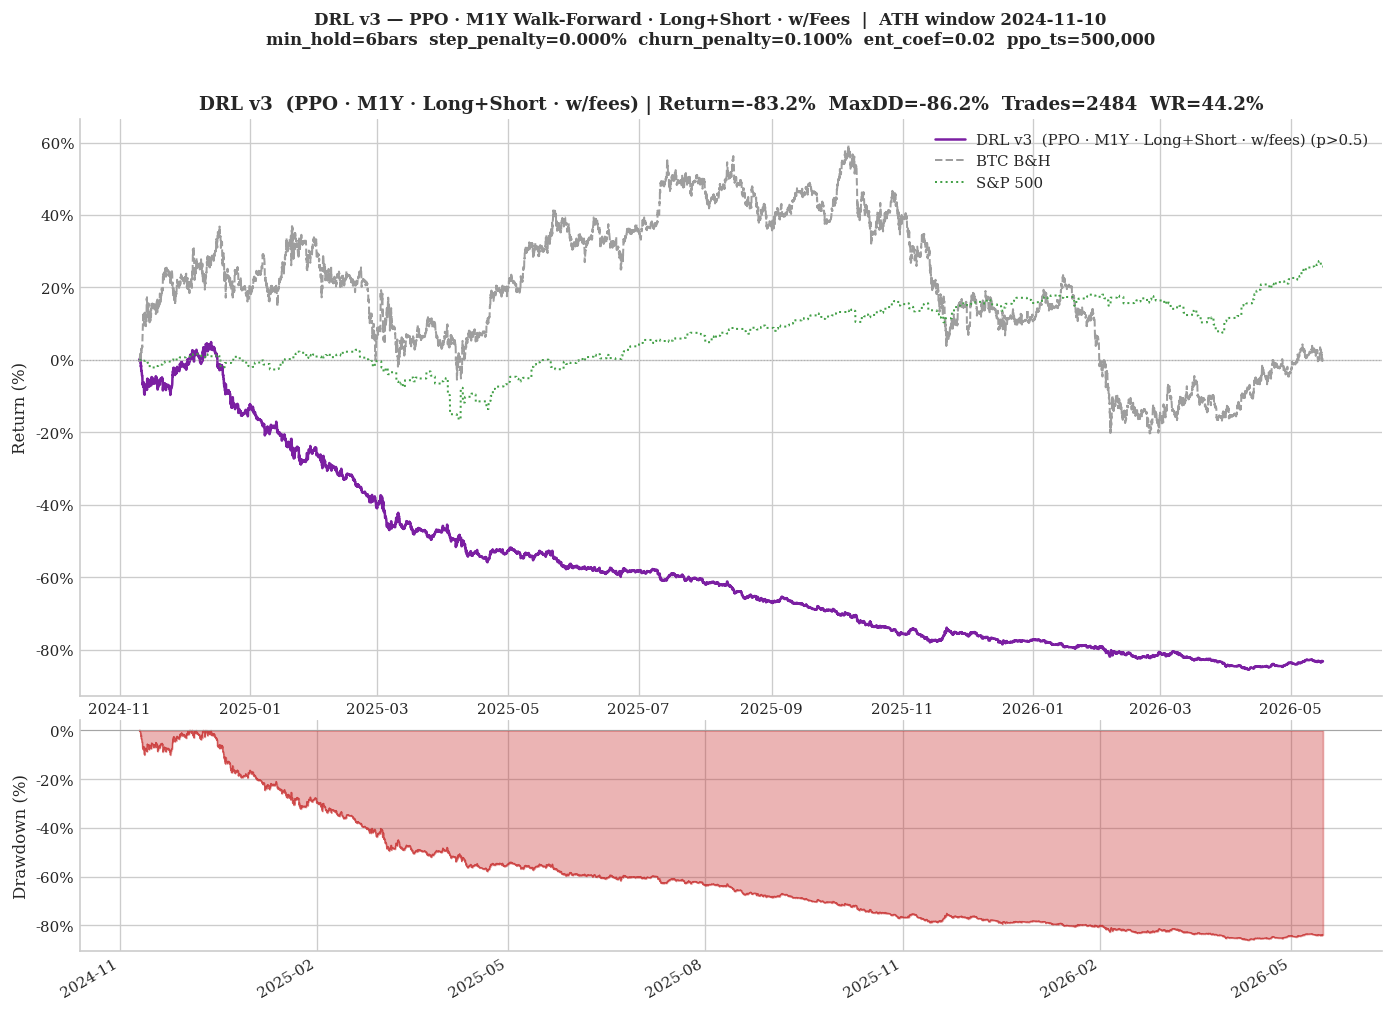

In [7]:
# ── PHASE 3: Equity / drawdown plot ──────────────────────────────────────────
fig = plot_equity_drawdown(
    oos_index_ath, eq_fees_ath, tdf_fees,
    bh_pct=bh_pct, sp500_pct=sp500_pct,
    label='DRL v3  (PPO \u00b7 M1Y \u00b7 Long+Short \u00b7 w/fees)',
    threshold=0.5, color=PURPLE,
)
fig.suptitle(
    f'DRL v3 \u2014 PPO \u00b7 M1Y Walk-Forward \u00b7 Long+Short \u00b7 w/Fees  |  ATH window {ATH_START.date()}\n'
    f'min_hold={MIN_HOLD}bars  step_penalty={STEP_PENALTY:.3%}  churn_penalty={CHURN_PENALTY:.3%}  '
    f'ent_coef={ENT_COEF}  ppo_ts={TOTAL_TIMESTEPS:,}',
    fontsize=10, fontweight='bold',
)
save_fig(fig, ARTS_DIR / '01_equity_drawdown.png')
plt.show()

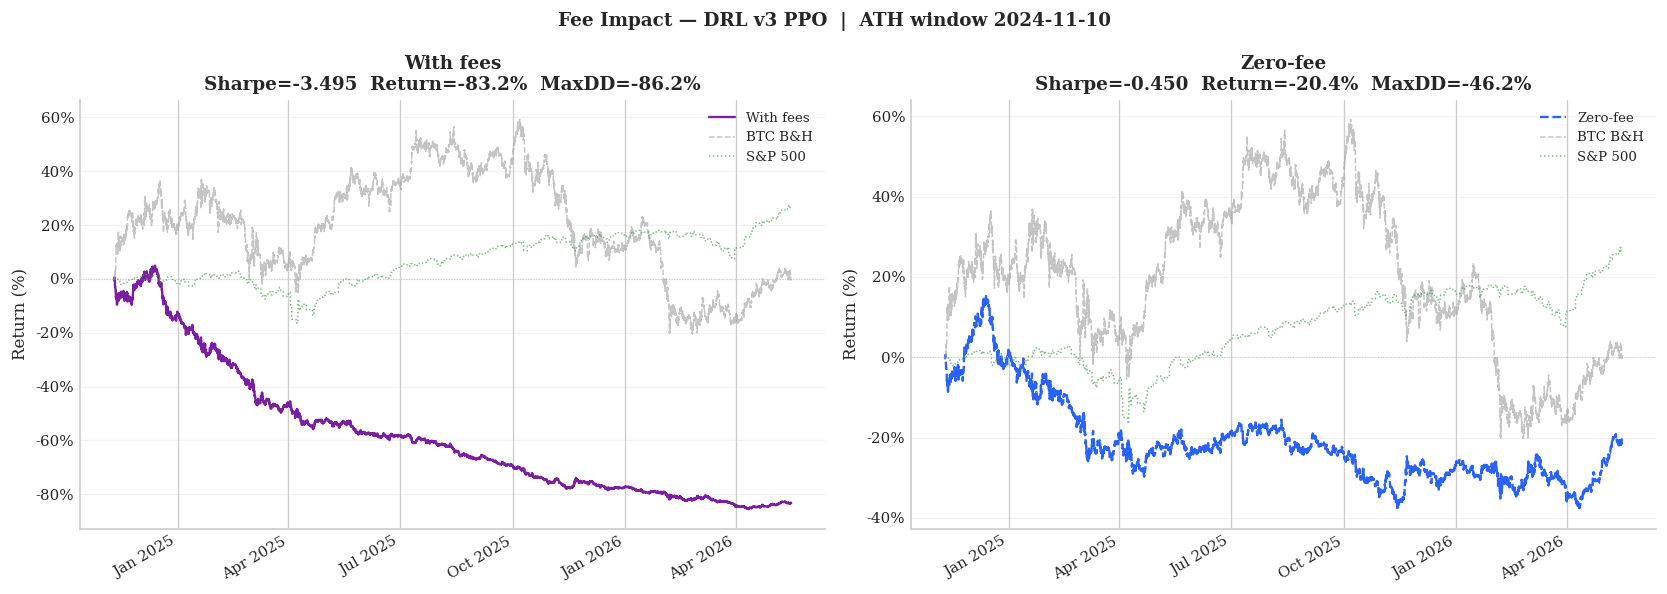

In [8]:
# ── Fee comparison plot ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (lbl, eq, color, ls) in zip(axes, [
    ('With fees', eq_fees_ath, PURPLE, '-'),
    ('Zero-fee',  eq_0fee_ath, BLUE,   '--'),
]):
    ax.plot(oos_index_ath, (eq-1)*100, color=color, lw=1.4, ls=ls, label=lbl)
    ax.plot(oos_index_ath, bh_pct, color=GREY, lw=0.9, ls='--', alpha=0.6, label='BTC B&H')
    if sp500_pct is not None:
        ax.plot(oos_index_ath, sp500_pct.values, color='#43A047', lw=0.9, ls=':', alpha=0.7, label='S&P 500')
    ax.axhline(0, color=GREY, lw=0.6, ls=':', alpha=0.5)
    sh=_sharpe(eq); ret=eq[-1]-1; dd=_maxdd(eq)
    ax.set_title(f'{lbl}\nSharpe={sh:.3f}  Return={ret:+.1%}  MaxDD={dd:.1%}', fontweight='bold')
    ax.set_ylabel('Return (%)'); ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f'{v:.0f}%'))
    ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.25)
    ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1,4,7,10]))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

fig.suptitle(f'Fee Impact \u2014 DRL v3 PPO  |  ATH window {ATH_START.date()}', fontweight='bold', fontsize=11)
fig.tight_layout()
save_fig(fig, ARTS_DIR / '02_fee_comparison.png')
plt.show()

Monthly stats (w/ fees, full OOS):
  Positive months : 2 / 29
  Avg monthly ret : -8.65%
  Median monthly  : -8.90%
  Best month      : +5.98%  (Apr 2026)
  Worst month     : -20.27%  (Oct 2025)


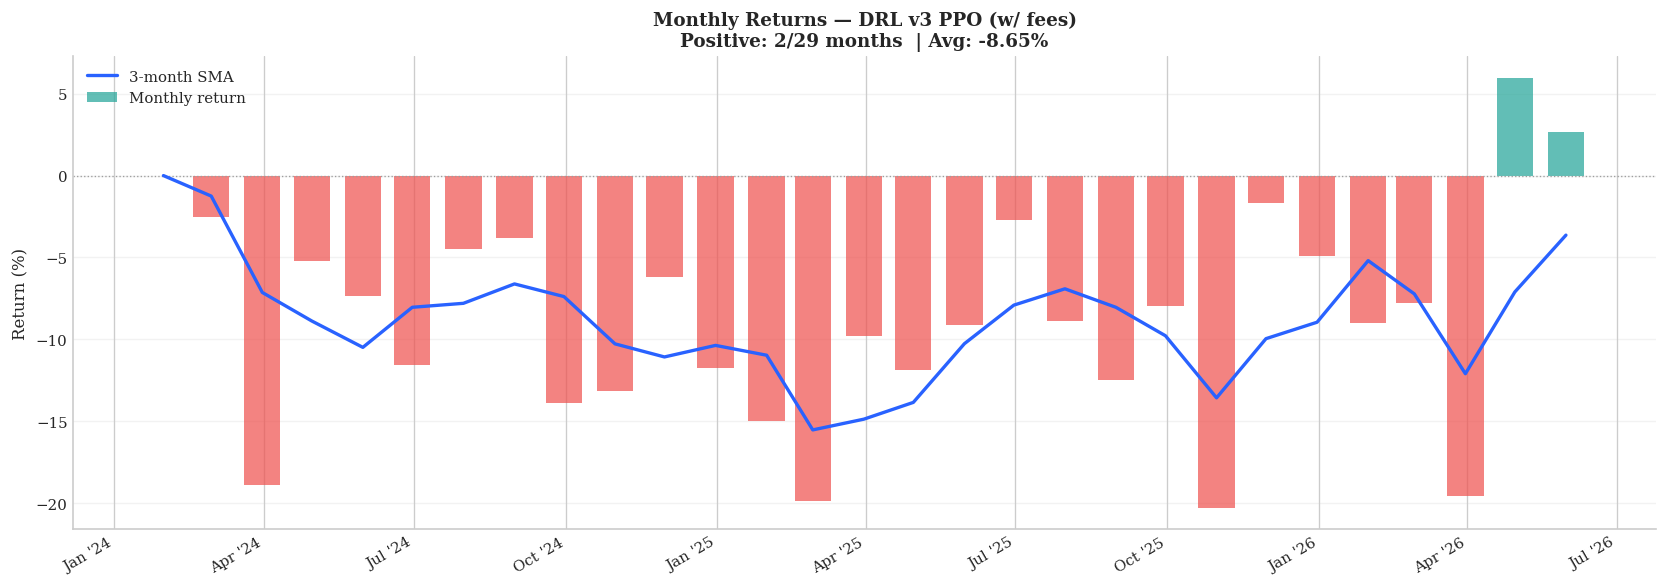

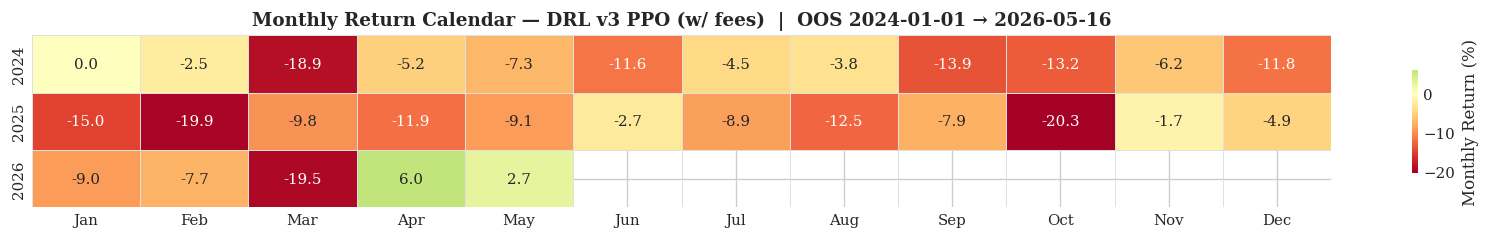

In [9]:
# ── Monthly return analysis ───────────────────────────────────────────────────
eq_full_series = pd.Series(eq_fees, index=oos_df.index)
monthly_eq  = eq_full_series.resample('ME').last()
monthly_ret = monthly_eq.pct_change().fillna(0) * 100
sma3 = monthly_ret.rolling(3, min_periods=1).mean()

print('Monthly stats (w/ fees, full OOS):')
print(f'  Positive months : {(monthly_ret>0).sum()} / {len(monthly_ret)}')
print(f'  Avg monthly ret : {monthly_ret.mean():+.2f}%')
print(f'  Median monthly  : {monthly_ret.median():+.2f}%')
print(f'  Best month      : {monthly_ret.max():+.2f}%  ({monthly_ret.idxmax().strftime("%b %Y")})')
print(f'  Worst month     : {monthly_ret.min():+.2f}%  ({monthly_ret.idxmin().strftime("%b %Y")})')

fig, ax = plt.subplots(figsize=(14, 5))
colors = [GREEN if r >= 0 else RED for r in monthly_ret.values]
ax.bar(monthly_ret.index, monthly_ret.values, color=colors, alpha=0.72, width=22, label='Monthly return')
ax.plot(monthly_ret.index, sma3.values, color=BLUE, lw=2.0, label='3-month SMA', zorder=5)
ax.axhline(0, color=GREY, lw=0.8, ls=':')
ax.set_ylabel('Return (%)')
ax.set_title(f'Monthly Returns \u2014 DRL v3 PPO (w/ fees)\n'
             f'Positive: {(monthly_ret>0).sum()}/{len(monthly_ret)} months  '
             f'| Avg: {monthly_ret.mean():+.2f}%', fontweight='bold')
ax.legend(); ax.grid(axis='y', alpha=0.25)
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1,4,7,10]))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b '%y"))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
fig.tight_layout()
save_fig(fig, ARTS_DIR / '03_monthly_returns.png')
plt.show()

# Calendar heatmap
cal_df = monthly_ret.to_frame('ret').copy()
cal_df['year'] = cal_df.index.year; cal_df['month'] = cal_df.index.month
pivot = cal_df.pivot(index='year', columns='month', values='ret')
pivot.columns = [calendar.month_abbr[m] for m in pivot.columns]
fig2, ax2 = plt.subplots(figsize=(14, max(2, len(pivot)*0.7)))
sns.heatmap(pivot, ax=ax2, cmap='RdYlGn', center=0, annot=True, fmt='.1f',
            linewidths=0.5, linecolor='#e0e0e0', cbar_kws={'label': 'Monthly Return (%)', 'shrink': 0.6},
            annot_kws={'size': 9})
ax2.set_title(f'Monthly Return Calendar \u2014 DRL v3 PPO (w/ fees)  |  OOS {OOS_START.date()} \u2192 {oos_df.index[-1].date()}',
              fontweight='bold')
ax2.set_xlabel(''); ax2.set_ylabel('')
fig2.tight_layout()
save_fig(fig2, ARTS_DIR / '04_monthly_heatmap.png')
plt.show()

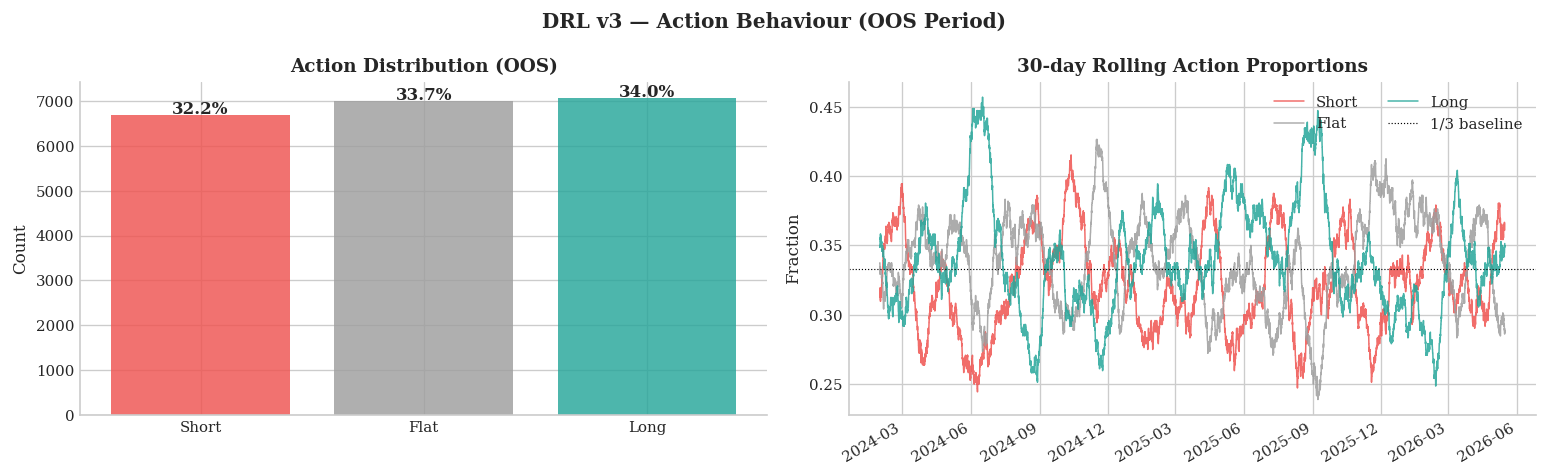

In [10]:
# ── Action distribution over OOS period ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
action_counts = pd.Series(_acts).value_counts().sort_index()
ac_labels = {-1: 'Short', 0: 'Flat', 1: 'Long'}
ac_colors = {-1: RED, 0: GREY, 1: GREEN}
bars = ax.bar([ac_labels[k] for k in action_counts.index],
              action_counts.values,
              color=[ac_colors[k] for k in action_counts.index], alpha=0.82)
for bar, v in zip(bars, action_counts.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+20,
            f'{v/len(_acts)*100:.1f}%', ha='center', fontsize=10, fontweight='bold')
ax.set_title('Action Distribution (OOS)', fontweight='bold')
ax.set_ylabel('Count')

ax = axes[1]
act_series = pd.Series(_acts, index=drl_signals.index)
roll_w = 720
for act_val, col, name in [(-1, RED, 'Short'), (0, GREY, 'Flat'), (1, GREEN, 'Long')]:
    frac = (act_series == act_val).rolling(roll_w).mean()
    ax.plot(frac.index, frac, color=col, lw=0.9, alpha=0.85, label=name)
ax.axhline(1/3, color='black', ls=':', lw=0.7, label='1/3 baseline')
ax.set_title('30-day Rolling Action Proportions', fontweight='bold')
ax.set_ylabel('Fraction'); ax.legend(ncol=2)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

fig.suptitle('DRL v3 \u2014 Action Behaviour (OOS Period)', fontweight='bold')
fig.tight_layout()
save_fig(fig, ARTS_DIR / '05_action_distribution.png')
plt.show()

In [11]:
# ── v1 / v2 / v3 comparison ───────────────────────────────────────────────────
v1_sig_path     = REPO_DIR / 'artifacts' / '07_drl_omni_0fee_v1' / 'drl_oos_signals.parquet'
v1_results_path = REPO_DIR / 'artifacts' / '07_drl_omni_0fee_v1' / 'results.json'
v2_results_path = REPO_DIR / 'artifacts' / '07_drl_omni_0fee_v2' / 'results.json'

def _load_res(p):
    try:
        with open(p) as f: return json.load(f)
    except Exception: return None

v1_res = _load_res(v1_results_path)
v2_res = _load_res(v2_results_path)

v2_flat_pct = (drl_signals == 0).mean() * 100
v3_wr = (tdf_fees['net'] > 0).mean() if len(tdf_fees) else 0.

def _fmt_res(res, key='backtest_wfees'):
    if res is None: return dict(n_trades='N/A', flat_pct='N/A', win_rate='N/A',
                                total_ret='N/A', sharpe='N/A', maxdd='N/A',
                                zero_ret='N/A', zero_sh='N/A')
    bt = res.get(key, {}); bt0 = res.get('backtest_0fee', {})
    ad = res.get('action_dist', {})
    fp = ad.get('0', 0) / max(sum(ad.values()), 1) * 100 if ad else 0.
    return dict(
        n_trades=bt.get('n_trades', 0),
        flat_pct=f'{fp:.1f}%',
        win_rate=f'{bt.get("win_rate",0):.1%}',
        total_ret=f'{bt.get("total_ret",0):+.1%}',
        sharpe=f'{bt.get("sharpe",0):.3f}',
        maxdd=f'{bt.get("maxdd",0):.1%}',
        zero_ret=f'{bt0.get("total_ret",0):+.1%}',
        zero_sh=f'{bt0.get("sharpe",0):.3f}',
    )

r1 = _fmt_res(v1_res); r2 = _fmt_res(v2_res)
r3 = dict(
    n_trades=len(tdf_fees),
    flat_pct=f'{v2_flat_pct:.1f}%',
    win_rate=f'{v3_wr:.1%}',
    total_ret=f'{eq_fees[-1]-1:+.1%}',
    sharpe=f'{_sharpe(eq_fees):.3f}',
    maxdd=f'{_maxdd(eq_fees):.1%}',
    zero_ret=f'{eq_0fee[-1]-1:+.1%}',
    zero_sh=f'{_sharpe(eq_0fee):.3f}',
)

print('\u250c' + '\u2500'*69 + '\u2510')
print(f'\u2502  {"METRIC":<28} {"DRL v1":>12} {"DRL v2":>12} {"DRL v3":>12}  \u2502')
print('\u251c' + '\u2500'*69 + '\u2524')
for label, k1, k2, k3 in [
    ('Trades (OOS)',       'n_trades',  'n_trades',  'n_trades'),
    ('Flat % (OOS)',       'flat_pct',  'flat_pct',  'flat_pct'),
    ('Win Rate (w/fees)',  'win_rate',  'win_rate',  'win_rate'),
    ('Return (w/fees)',    'total_ret', 'total_ret', 'total_ret'),
    ('Sharpe (w/fees)',    'sharpe',    'sharpe',    'sharpe'),
    ('Max Drawdown',       'maxdd',     'maxdd',     'maxdd'),
]:
    print(f'\u2502  {label:<28} {str(r1[k1]):>12} {str(r2[k2]):>12} {str(r3[k3]):>12}  \u2502')
print('\u251c' + '\u2500'*69 + '\u2524')
for label, k1, k2, k3 in [
    ('Return (0-fee)',  'zero_ret', 'zero_ret', 'zero_ret'),
    ('Sharpe (0-fee)', 'zero_sh',  'zero_sh',  'zero_sh'),
]:
    print(f'\u2502  {label:<28} {str(r1[k1]):>12} {str(r2[k2]):>12} {str(r3[k3]):>12}  \u2502')
print('\u2514' + '\u2500'*69 + '\u2518')


┌─────────────────────────────────────────────────────────────────────┐
│  METRIC                             DRL v1       DRL v2       DRL v3  │
├─────────────────────────────────────────────────────────────────────┤
│  Trades (OOS)                         2483         2368         2484  │
│  Flat % (OOS)                        33.0%        30.2%        33.7%  │
│  Win Rate (w/fees)                   44.0%        44.3%        44.2%  │
│  Return (w/fees)                    -86.0%       -92.5%       -93.0%  │
│  Sharpe (w/fees)                    -2.292       -3.050       -3.121  │
│  Max Drawdown                       -87.2%       -93.3%       -94.4%  │
├─────────────────────────────────────────────────────────────────────┤
│  Return (0-fee)                     +63.9%       -21.6%       -17.2%  │
│  Sharpe (0-fee)                      0.578       -0.288       -0.223  │
└─────────────────────────────────────────────────────────────────────┘


In [12]:
# ── Save results.json ─────────────────────────────────────────────────────────
def _bt_metrics(eq, tdf, label):
    wr  = float((tdf['net']>0).mean()) if len(tdf) else 0.
    n_l = int((tdf['direction']=='long').sum())  if len(tdf) else 0
    n_s = int((tdf['direction']=='short').sum()) if len(tdf) else 0
    return {'label': label, 'n_trades': len(tdf), 'n_long': n_l, 'n_short': n_s,
            'win_rate': round(wr, 4),
            'total_ret': round(float(eq[-1]-1), 4),
            'sharpe': round(_sharpe(eq), 4),
            'maxdd': round(_maxdd(eq), 4),
            'ath_total_ret': round(float(_rebase(eq)[-1]-1), 4),
            'ath_sharpe': round(_sharpe(_rebase(eq)), 4),
            'ath_maxdd': round(_maxdd(_rebase(eq)), 4)}

results = {
    'notebook': '07_drl_omni_0fee_v3',
    'version': 'v3',
    'created': pd.Timestamp.now().isoformat(),
    'algorithm': 'PPO (Stable-Baselines3)',
    'scheme': 'M1Y (1-year sliding)',
    'direction': 'long+short',
    'v3_fixes': {
        'min_hold': MIN_HOLD,
        'step_penalty': STEP_PENALTY,
        'churn_penalty': CHURN_PENALTY,
        'ent_coef': ENT_COEF,
        'total_timesteps': TOTAL_TIMESTEPS,
        'episode_len': EPISODE_LEN,
        'randomised_reset': True,
    },
    'oos_period': f'{OOS_START.date()} \u2192 {oos_df.index[-1].date()}',
    'ath_window': f'{ATH_START.date()} \u2192 {oos_ath.index[-1].date()}',
    'n_features': len(agent.features),
    'window_size': 24,
    'total_timesteps_per_fold': TOTAL_TIMESTEPS,
    'fees': {'taker': TAKER_FEE, 'funding_h': FUNDING_H},
    'action_dist': {str(k): int(v) for k, v in pd.Series(_acts).value_counts().sort_index().items()},
    'backtest_wfees': _bt_metrics(eq_fees, tdf_fees, 'w_fees'),
    'backtest_0fee':  _bt_metrics(eq_0fee, tdf_0fee, '0_fee'),
    'monthly_returns': {
        'mean_pct': round(float(monthly_ret.mean()), 3),
        'median_pct': round(float(monthly_ret.median()), 3),
        'std_pct': round(float(monthly_ret.std()), 3),
        'positive_months': int((monthly_ret > 0).sum()),
        'total_months': int(len(monthly_ret)),
    }
}

out_path = ARTS_DIR / 'results.json'
with open(out_path, 'w') as f:
    json.dump(results, f, indent=2)
print(f'Saved \u2192 {out_path}')
print(json.dumps(results, indent=2)[:1500])

Saved → /Users/wojciech.neuman/Documents/hybrid-multi-agent-trading-system/artifacts/07_drl_omni_0fee_v3/results.json
{
  "notebook": "07_drl_omni_0fee_v3",
  "version": "v3",
  "created": "2026-06-03T02:59:49.898048",
  "algorithm": "PPO (Stable-Baselines3)",
  "scheme": "M1Y (1-year sliding)",
  "direction": "long+short",
  "v3_fixes": {
    "min_hold": 6,
    "step_penalty": 0.0,
    "churn_penalty": 0.001,
    "ent_coef": 0.02,
    "total_timesteps": 500000,
    "episode_len": 1000,
    "randomised_reset": true
  },
  "oos_period": "2024-01-01 \u2192 2026-05-16",
  "ath_window": "2024-11-10 \u2192 2026-05-16",
  "n_features": 19,
  "window_size": 24,
  "total_timesteps_per_fold": 500000,
  "fees": {
    "taker": 0.0005,
    "funding_h": 7.7e-06
  },
  "action_dist": {
    "-1": 6700,
    "0": 7009,
    "1": 7076
  },
  "backtest_wfees": {
    "label": "w_fees",
    "n_trades": 2484,
    "n_long": 1291,
    "n_short": 1193,
    "win_rate": 0.4416,
    "total_ret": -0.9296,
    "shar